In [106]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

import pulser
from pulser.waveforms import InterpolatedWaveform

import emu_sv
from emu_sv import SVConfig, SVBackend, Occupation, StateResult, StateVector, Fidelity

from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse

from pulser import AnalogDevice

## 1. Build the 3×3 register and the bare adiabatic pulse

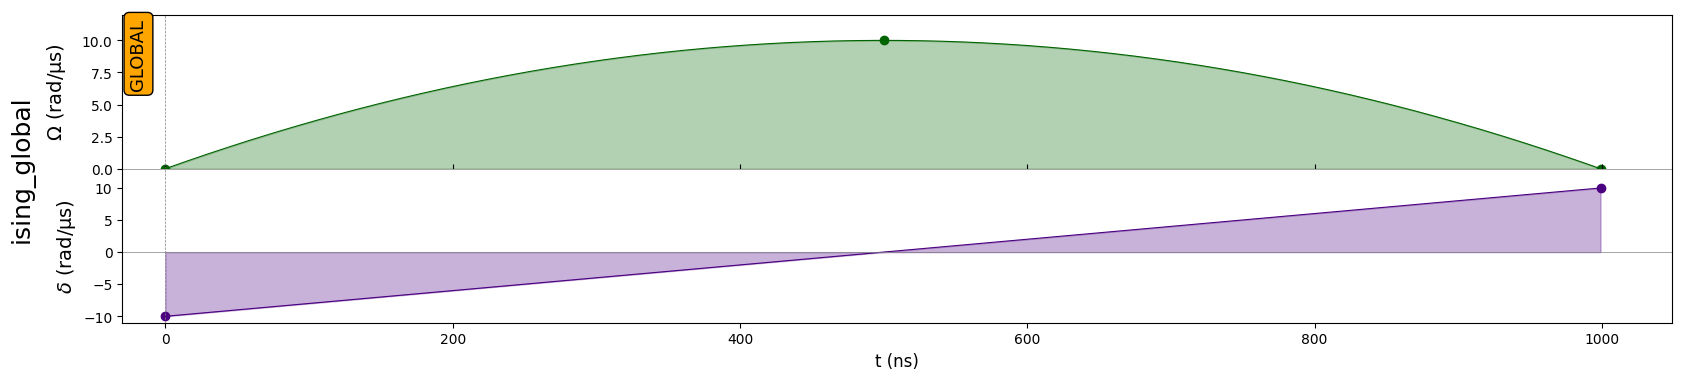

Atoms: 9
Duration: 1000 ns,  dt: 10 ns,  steps: 100


In [107]:
n_side = 3
n_atoms = n_side * n_side
spacing = 7.0  

reg = pulser.Register.square(n_side, prefix="q", spacing=spacing)

# --- Bare adiabatic protocol ------------------------------------------------
# Ω(t) ≡ 0  →  pure detuning sweep
# δ(t) goes from -delta_max to +delta_max linearly
T = 1000          # total duration in ns
dt = 10           # emulation timestep in ns
delta_max = 10.0  # rad/μs (Pulser convention)
omega_max = 10.0   # required by the problem statement
C6= AnalogDevice.interaction_coeff


adiabatic_pulse = pulser.Pulse(
    InterpolatedWaveform(T, [0,omega_max, 0]),         # Ω(t) = 0
    InterpolatedWaveform(T, [-delta_max, delta_max]),         # δ ramp
    0.0,
)

seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()
print(f"Atoms: {n_atoms}")
print(f"Duration: {T} ns,  dt: {dt} ns,  steps: {T // dt}")

In [89]:
config_for_cd = SVConfig(dt=dt, observables=[])

# LCD only
cd_lcd = CounterDiabaticPulse(seq, config_for_cd)
seq_data_lcd = cd_lcd.solver(cold_fourier=0)

# COLD 
cd_cold = CounterDiabaticPulse(seq, config_for_cd)
seq_data_cold = cd_cold.solver(cold_fourier=3, nruns=50, lr=1e-2)

/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_sv/sv_config.py:83: UserWarning: 'SVConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


LCD  loss = 4.580067e+01  
step    0  loss = 4.580067e+01  
step    1  loss = 4.558962e+01  
step    2  loss = 4.538363e+01  
step    3  loss = 4.518262e+01  
step    4  loss = 4.498649e+01  
step    5  loss = 4.479517e+01  
step    6  loss = 4.460856e+01  
step    7  loss = 4.442658e+01  
step    8  loss = 4.424914e+01  
step    9  loss = 4.407616e+01  
step   10  loss = 4.390754e+01  
step   11  loss = 4.374318e+01  
step   12  loss = 4.358300e+01  
step   13  loss = 4.342689e+01  
step   14  loss = 4.327474e+01  
step   15  loss = 4.312644e+01  
step   16  loss = 4.298189e+01  
step   17  loss = 4.284096e+01  
step   18  loss = 4.270352e+01  
step   19  loss = 4.256945e+01  
step   20  loss = 4.243861e+01  
step   21  loss = 4.231087e+01  
step   22  loss = 4.218608e+01  
step   23  loss = 4.206409e+01  
step   24  loss = 4.194476e+01  
step   25  loss = 4.182794e+01  
step   26  loss = 4.171348e+01  
step   27  loss = 4.160125e+01  
step   28  loss = 4.149111e+01  
step   29  loss 

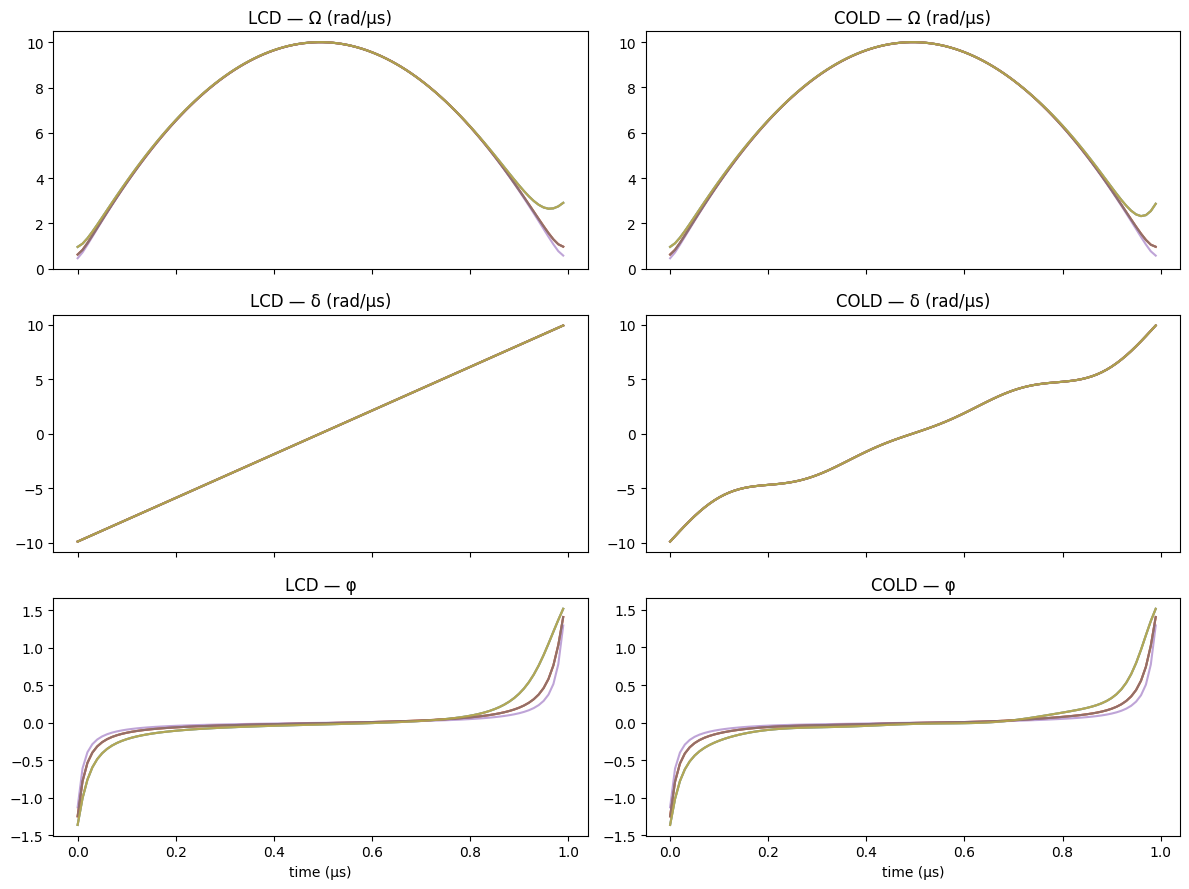

In [94]:
def to_np(t):
    return t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)

times = np.arange(seq_data_lcd.omega.shape[0]) * dt / 1000  # in μs

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for col, (label, sd) in enumerate([("LCD", seq_data_lcd), ("COLD", seq_data_cold)]):
    omega = to_np(sd.omega)
    delta = to_np(sd.delta)
    phi   = to_np(sd.phi)
    for i in range(n_atoms):
        axes[0, col].plot(times, omega[:, i], alpha=0.6)
        axes[1, col].plot(times, delta[:, i], alpha=0.6)
        axes[2, col].plot(times, phi[:, i],   alpha=0.6)
    axes[0, col].set_title(f"{label} — Ω (rad/μs)")
    axes[1, col].set_title(f"{label} — δ (rad/μs)")
    axes[2, col].set_title(f"{label} — φ")
    axes[2, col].set_xlabel("time (μs)")
fig.tight_layout()
plt.show()

In [ ]:
# Build exact ground state of the Rydberg Hamiltonian at the end of the evolution
from scipy.linalg import eigh


dim = 2**n_atoms
sx = np.array([[0.0, 1.0], [1.0, 0.0]])
sz = np.array([[1.0, 0.0], [0.0, -1.0]])
I2 = np.eye(2)
positions=reg._coords

def site_op(op, site, n_qubits):
    result = np.array([[1.0]])
    for i in range(n_qubits):
        result = np.kron(result, op if i == site else I2)
    return result

sx_list = [site_op(sx, i, n_atoms) for i in range(n_atoms)]
sz_list = [site_op(sz, i, n_atoms) for i in range(n_atoms)]
n_list = [(np.eye(dim) - sz_list[i]) / 2.0 for i in range(n_atoms)] 

# H = Σ_{i<j} J̃_ij n_i n_j  +  (Ω̃_c/2) Σ σ^x_i  -  δ̃_f Σ n_i
H_exact = np.zeros((dim, dim))

for i in range(n_atoms):
    for j in range(i + 1, n_atoms):
        r_ij = np.linalg.norm(positions[i]-positions[j])
        J_ij = C6 / r_ij**6
        H_exact += J_ij * (n_list[i] @ n_list[j])

for i in range(n_atoms):
    H_exact += -delta_max * n_list[i]

# Diagonalize
eigenvalues, eigenvectors = eigh(H_exact)
gs_energy = eigenvalues[0]
gs_state = eigenvectors[:, 0]  # exact ground state vector

amplitudes = {}
for idx in range(dim):
    amp = complex(gs_state[idx])
    bitstring = format(idx, f"0{n_atoms}b")
    rg_string = bitstring.replace("1", "r").replace("0", "g")
    amplitudes[rg_string] = amp

target_state = StateVector.from_state_amplitudes(
    eigenstates=("r", "g"),
    amplitudes=amplitudes,
)

In [118]:

config = SVConfig(
    dt=10,
    observables=[Fidelity(evaluation_times=[1.0], state=target_state)])

print("Baseline schedule...")
backend = SVBackend(seq, config=config)
results_baseline = backend.run()

print("Emulating LCD schedule...")
results_lcd=SVBackend._run_from_sequence_data(seq_data_lcd, config)

print("Emulating COLD schedule...")
results_cold=SVBackend._run_from_sequence_data(seq_data_cold, config)

Baseline schedule...
step = 1/100, RSS = 9.432 MB, Δt = 0.008 s


step = 2/100, RSS = 9.432 MB, Δt = 0.008 s
step = 3/100, RSS = 9.432 MB, Δt = 0.008 s
step = 4/100, RSS = 9.432 MB, Δt = 0.009 s
step = 5/100, RSS = 9.432 MB, Δt = 0.008 s
step = 6/100, RSS = 9.432 MB, Δt = 0.009 s
step = 7/100, RSS = 9.432 MB, Δt = 0.009 s
step = 8/100, RSS = 9.432 MB, Δt = 0.009 s
step = 9/100, RSS = 9.432 MB, Δt = 0.010 s
step = 10/100, RSS = 9.432 MB, Δt = 0.010 s
step = 11/100, RSS = 9.432 MB, Δt = 0.010 s
step = 12/100, RSS = 9.432 MB, Δt = 0.010 s
step = 13/100, RSS = 9.432 MB, Δt = 0.011 s
step = 14/100, RSS = 9.432 MB, Δt = 0.011 s
step = 15/100, RSS = 9.432 MB, Δt = 0.011 s
step = 16/100, RSS = 9.432 MB, Δt = 0.011 s
step = 17/100, RSS = 9.432 MB, Δt = 0.011 s
step = 18/100, RSS = 9.432 MB, Δt = 0.011 s
step = 19/100, RSS = 9.432 MB, Δt = 0.011 s
step = 20/100, RSS = 9.432 MB, Δt = 0.011 s
step = 21/100, RSS = 9.432 MB, Δt = 0.011 s
step = 22/100, RSS = 9.432 MB, Δt = 0.011 s
step = 23/100, RSS = 9.432 MB, Δt = 0.011 s
step = 24/100, RSS = 9.432 MB, Δt = 0.01

In [120]:
fid_baseline = results_baseline.get_tagged_results()['fidelity']
fid_lcd  = results_lcd.get_tagged_results()['fidelity']
fid_cold = results_cold.get_tagged_results()['fidelity']

print(f"Baseline  ground-state fidelity: {fid_baseline}")
print(f"LCD  ground-state fidelity: {fid_lcd}")
print(f"COLD ground-state fidelity: {fid_cold}")

Baseline  ground-state fidelity: [tensor(4.0655e-23, dtype=torch.float64)]
LCD  ground-state fidelity: [tensor(1.4863e-20, dtype=torch.float64)]
COLD ground-state fidelity: [tensor(2.2981e-19, dtype=torch.float64)]
